In [1]:
import polars as pl
import numpy as np
from pathlib import Path
import bisect
import pandas as pd

In [2]:
ROOT = Path("/data/xujiayi/xjy/l2")
DATE = "20260624"
EXCHANGE = "sz"

In [3]:
order = pl.read_parquet(ROOT/"proc"/DATE/f"{EXCHANGE}wt.pq").filter((pl.col('TransactTime')>pl.time(9,30)) & (pl.col('TransactTime')<pl.time(14,57)))
cancel = pl.read_parquet(ROOT/"proc"/DATE/f"{EXCHANGE}cancel.pq").filter((pl.col('TransactTime')>pl.time(9,30)) & (pl.col('TransactTime')<pl.time(14,57)))
deal = pl.read_parquet(ROOT/"proc"/DATE/f"{EXCHANGE}cj.pq").filter((pl.col('TransactTime')>pl.time(9,30)) & (pl.col('TransactTime')<pl.time(14,57)))
shot = pl.read_parquet(ROOT/"proc"/DATE/f"{EXCHANGE}shot_1m.pq").filter((pl.col('BarTime')>=pl.time(9,30)) & (pl.col('BarTime')<=pl.time(14,57)))

#### 订单维度

In [19]:
# 挂买
buy_order = order.filter(pl.col('Side')==1)
buy_order = buy_order.join_asof(
    shot,
    left_on="TransactTime",
    right_on="BarTime",
    by="SecurityID",
    strategy="backward",
    check_sortedness=False,
).with_columns(
    pl.when((pl.col('Price') >= pl.col('AskPrice1')) & (pl.col('OrderQty') >= pl.col('AskQty1'))).then(1)
    .when((pl.col('Price') >= pl.col('AskPrice1')) & (pl.col('OrderQty') < pl.col('AskQty1'))).then(2)
    .when((pl.col('Price') > pl.col('BidPrice1')) & (pl.col('Price') < pl.col('AskPrice1'))).then(3)
    .when(pl.col('Price') == pl.col('BidPrice1')).then(4)
    .otherwise(5)
    .alias('PassionLevel')
).select(order.columns+['PassionLevel'])

# 挂卖
sell_order = order.filter(pl.col('Side')==-1)
sell_order = sell_order.join_asof(
    shot,
    left_on="TransactTime",
    right_on="BarTime",
    by="SecurityID",
    strategy="backward",
    check_sortedness=False,
).with_columns(
    pl.when((pl.col('Price') <= pl.col('BidPrice1')) & (pl.col('OrderQty') >= pl.col('BidQty1'))).then(1)
    .when((pl.col('Price') <= pl.col('BidPrice1')) & (pl.col('OrderQty') < pl.col('BidQty1'))).then(2)
    .when((pl.col('Price') < pl.col('AskPrice1')) & (pl.col('Price') > pl.col('BidPrice1'))).then(3)
    .when(pl.col('Price') == pl.col('AskPrice1')).then(4)
    .otherwise(5)
    .alias('PassionLevel')
).select(order.columns+['PassionLevel'])


#### 成交维度

In [ ]:
deal = deal.with_columns(
    pl.when((0<=pl.col('OrderQty')) & (pl.col('OrderQty')<50000)).then(1)
    .when((50000<=pl.col('OrderQty')) & (pl.col('OrderQty')<300000)).then(2)
    .when((300000<=pl.col('OrderQty')) & (pl.col('OrderQty')<1000000)).then(3)
    .otherwise(4)
    .alias('Size')
)
# 主买
active_buy = deal.filter(pl.col('BidApplSeqNum')>pl.col('OfferApplSeqNum'))
# 主卖
active_sell = deal.filter(pl.col('BidApplSeqNum')<pl.col('OfferApplSeqNum'))


ChannelNo,ApplSeqNum,BidApplSeqNum,OfferApplSeqNum,SecurityID,Price,OrderQty,TransactTime,LocalTime,SeqNo,Side,Size
i64,i64,i64,i64,i64,f64,i64,time,str,i64,i32,i32
2021,55760,55759,2125,159995,2.81,16700,09:30:00.010,"""09:30:00.083""",606936,1,1
2021,55761,55759,13337,159995,2.81,10000,09:30:00.010,"""09:30:00.083""",606937,1,1
2021,55762,55759,40814,159995,2.81,20400,09:30:00.010,"""09:30:00.083""",606938,1,1
2021,55763,55759,40822,159995,2.81,10800,09:30:00.010,"""09:30:00.083""",606939,1,1
2021,55764,55759,44003,159995,2.81,5000,09:30:00.010,"""09:30:00.083""",606940,1,1
…,…,…,…,…,…,…,…,…,…,…,…
2011,60843536,60843535,60841324,300497,22.12,100,14:56:59.990,"""14:57:00.003""",172095491,1,1
2011,60843537,60843535,60842264,300497,22.12,600,14:56:59.990,"""14:57:00.003""",172095492,1,1
2015,61052524,61052523,60965867,2921,26.67,100,14:56:59.990,"""14:57:00.004""",172095495,1,1


#### 时间维度

In [ ]:
qty_bin = order.filter(pl.col('SecurityID')==300221).sort(['TransactTime','ApplSeqNum']).join_asof(
    shot.select(["BarTime","SecurityID"]),
    left_on="TransactTime",
    right_on="BarTime",
    by="SecurityID",
    strategy="backward",
    check_sortedness=False,
).group_by('BarTime').agg(pl.col('OrderQty').sum()//100).sort('BarTime')
qty_bin

BarTime,OrderQty
time,i64
09:30:00,90922
09:31:00,27540
09:32:00,17194
09:33:00,17084
09:34:00,14952
…,…
14:52:00,6284
14:53:00,7104
14:54:00,5905


In [ ]:
def cal_surround_mean(df, n, limit):
    surrounding_mean = 0
    for i in range(1, n//2+1):
        surrounding_mean += pl.col('OrderQty').shift(i).fill_null(0) +  pl.col('OrderQty').shift(-i).fill_null(0)
    df = df.with_columns((surrounding_mean/n).alias('surround_mean'))
    ab_df = df.filter( pl.col('OrderQty')>pl.col('surround_mean')*limit )
    ab_df = ab_df.with_columns( (pl.col('OrderQty')/pl.col('surround_mean')).alias('ratio') )
    return ab_df

limit = 1.2
n=5
cal_surround_mean(qty_bin, n, limit)  # 1.2:47%, 1.5:25%

BarTime,OrderQty,surround_mean,ratio
time,i64,f64,f64
09:30:00,90922,8946.8,10.162516
09:34:00,14952,11753.8,1.272099
09:36:00,11931,8929.0,1.336208
09:39:00,9786,7146.4,1.369361
09:41:00,10720,8191.4,1.30869
…,…,…,…
14:49:00,5516,3863.6,1.427684
14:52:00,6284,4500.8,1.396196
14:53:00,7104,4657.0,1.525446


In [10]:
111/237

0.46835443037974683

<Axes: xlabel='BarTime'>

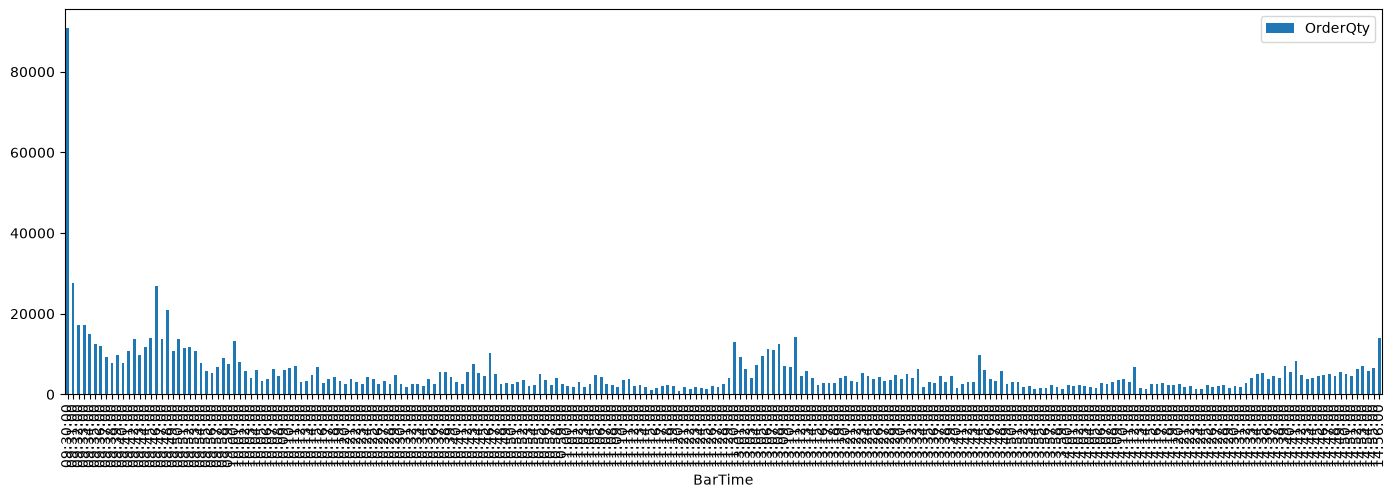

In [151]:
import matplotlib.pyplot as plt
qty_bin.plot(kind='bar', figsize=(17,5))

In [ ]:
buy_passionlevel_count = buy_order.group_by(['SecurityID','PassionLevel']).agg(pl.col('PassionLevel').count().alias('LevelCount')).sort(['SecurityID','PassionLevel'])
buy_passionlevel_count = buy_passionlevel_count.with_columns(
    (pl.col('LevelCount')/pl.col('LevelCount').sum().over('SecurityID')).alias('LevelProportion')
)

sell_passionlevel_count = sell_order.group_by(['SecurityID','PassionLevel']).agg(pl.col('PassionLevel').count().alias('LevelCount')).sort(['SecurityID','PassionLevel'])
sell_passionlevel_count = sell_passionlevel_count.with_columns(
    (pl.col('LevelCount')/pl.col('LevelCount').sum().over('SecurityID')).alias('LevelProportion')
)

all_securities = buy_passionlevel_count.select('SecurityID').unique().vstack(
    sell_passionlevel_count.select('SecurityID').unique()
).unique()
all_levels = pl.DataFrame({'PassionLevel': [1, 2, 3, 4, 5]})
all_combinations = all_securities.join(all_levels, how='cross')

passionlevel_count = (
    all_combinations
    .join(
        buy_passionlevel_count,
        on=['SecurityID', 'PassionLevel'],
        how='left'
    ).with_columns([
        pl.col('LevelCount').fill_null(0).alias('LevelCount_buy'),
        pl.col('LevelProportion').fill_null(0).alias('LevelProportion_buy')
    ]).drop(['LevelCount', 'LevelProportion'])
    .join(
        sell_passionlevel_count,
        on=['SecurityID', 'PassionLevel'],
        how='left'
    ).with_columns([
        pl.col('LevelCount').fill_null(0).alias('LevelCount_sell'),
        pl.col('LevelProportion').fill_null(0).alias('LevelProportion_sell')
    ]).drop(['LevelCount', 'LevelProportion'])
).sort(['SecurityID','PassionLevel'])
passionlevel_count

SecurityID,PassionLevel,LevelCount_buy,LevelProportion_buy,LevelCount_sell,LevelProportion_sell
i64,i64,u32,f64,u32,f64
1,1,236,0.003878,1149,0.022379
1,2,18512,0.304224,23093,0.449788
1,3,649,0.010666,858,0.016711
1,4,23563,0.387231,17302,0.336995
1,5,17890,0.294002,8940,0.174126
…,…,…,…,…,…
302132,1,1869,0.104565,2861,0.144131
302132,2,6445,0.36058,6306,0.317683
302132,3,1718,0.096117,2446,0.123224


In [87]:
###订单激进度净偏向
factor_tilt = passionlevel_count.with_columns(
    pl.when(pl.col('PassionLevel')==1).then(5)
    .when(pl.col('PassionLevel')==2).then(4)
    .when(pl.col('PassionLevel')==3).then(3)
    .when(pl.col('PassionLevel')==4).then(2)
    .when(pl.col('PassionLevel')==5).then(1)
    .otherwise(0)
    .alias('LevelScore')
).with_columns(
    pl.col('LevelScore')*(pl.col('LevelProportion_buy')-pl.col('LevelProportion_sell')).alias('factor_tilt')
).group_by('SecurityID').agg(pl.col('LevelScore').sum())


In [88]:
ticks = np.load("/data/xujiayi/xjy/axis/ticks.npy", allow_pickle=True)
dates = np.load("/data/xujiayi/xjy/axis/dates.npy", allow_pickle=True)

factor_tilt = factor_tilt.to_pandas().set_index('SecurityID')
factor_tilt.index = factor_tilt.index.astype(str).str.zfill(6)
factor_tilt = factor_tilt.reindex(ticks)

In [84]:
import pymssql

JY_CONFIG = {
    "server": '10.10.0.102',
    "user": 'jydbReader',
    "password": 'jy@9043!Reader',
    "database": 'jydb',
    "charset": 'cp936'
}
JY_CONN = pymssql.connect(**JY_CONFIG)

sql_field = f'''select
                    C.SecuCode as "tick",
                    A.ChangePCT as "pct"
                from QT_StockPerformance A
                left join SecuMain C
                on A.InnerCode = C.InnerCode
                where A.TradingDay='{"2026-06-26"}'
                    and C.SecuMarket in (83,90)
                    and C.SecuCategory=1
                union all
                select
                    C.SecuCode as "tick",
                    B.ChangePCT as "pct"
                from LC_STIBPerformance B
                left join SecuMain C
                on B.InnerCode = C.InnerCode
                where B.TradingDay='{"2026-06-26"}'
                    and C.SecuMarket in (83,90)
                    and C.SecuCategory=1
                '''
d_pct = pl.read_database(sql_field, JY_CONN).sort('tick')
d_pct = d_pct.to_pandas().set_index('tick').reindex(ticks)
d_pct

,pct
tick,
000001,-1.8234
000002,2.0339
000004,7.6923
000005,NaN
000006,-2.5815
...,...
688805,-5.5644
688807,-10.2325
688809,-5.2597


In [110]:
import bottleneck as bn

label = d_pct.values.astype(float).reshape(1,-1)
pred1 = factor_tilt.values.astype(float).reshape(1,-1)

def corr(a, b, axis):
    b[np.isnan(a)] = np.nan
    a[np.isnan(b)] = np.nan
    arr = (
            (bn.nanmean(a * b, axis=axis) - bn.nanmean(a, axis=axis) * bn.nanmean(b, axis=axis))
            / (bn.nanstd(a, axis=axis) + 1e-6)
            / (bn.nanstd(b, axis=axis) + 1e-6)
    )
    bn.replace(arr, np.nan, 0)
    arr[np.isinf(arr)] = 0
    return arr

def IC(y_, y):
    ics = corr(y_.copy(), y.copy(), axis=1)
    return ics

def rankIC(y_, y):
    rank_ics = corr(bn.nanrankdata(y_.copy(), axis=1), bn.nanrankdata(y.copy(), axis=1), axis=1)
    return rank_ics

In [113]:
rankIC(pred1, label)

array([-0.08575076])

In [106]:
factor_extreme = (
    passionlevel_count
    .group_by('SecurityID')
    .agg(
        (pl.col('LevelCount_buy').filter(pl.col('PassionLevel')==1).first() + 
         pl.col('LevelCount_sell').filter(pl.col('PassionLevel')==1).first()) / 
        (pl.col('LevelCount_buy').filter(pl.col('PassionLevel')==5).first() + 
         pl.col('LevelCount_sell').filter(pl.col('PassionLevel')==5).first())
        .alias('factor_extreme')
    )
)

In [108]:
factor_extreme = factor_extreme.to_pandas().set_index('SecurityID')
factor_extreme.index = factor_extreme.index.astype(str).str.zfill(6)
factor_extreme = factor_extreme.reindex(ticks)
factor_extreme

,LevelCount_buy
SecurityID,
000001,0.051621
000002,0.006516
000004,0.041916
000005,NaN
000006,0.136749
...,...
688805,NaN
688807,NaN
688809,NaN


In [112]:
label = d_pct.values.astype(float).reshape(1,-1)
pred2 = factor_extreme.values.astype(float).reshape(1,-1)

rankIC(pred2, label)

array([-0.05752338])

In [114]:
rankIC(pred1*pred2, label)

array([-0.031836])